In [1]:
#For multiple values G_mu and P, with integration methods quad and trapezoid, and for higher l values(was encountering overflow error), I modified the prefactor of power spectrum by introducing gamma function
# Having fluctuations in larger l values

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, cumulative_trapezoid
from scipy.interpolate import interp1d
from scipy.special import spherical_jn, erf, gammaln
import math

In [2]:
# ---------------------------
# Cosmological parameters
# ---------------------------
c_tilde = 0.23
H0 = 70.0  # Hubble constant in km/s/Mpc
h = H0 / 299792.458  # Convert H0 to 1/Mpc
Omega_m = 0.3
Omega_L = 0.7
chi_star = 14000.0  # Conformal distance to last scattering (Mpc)


In [3]:
# ------------------------------
# Functions for a(chi), H(chi), z(chi)
# ------------------------------
z_vals = np.linspace(0.01, 1100, 1000)
H_z = h * np.sqrt(Omega_m * (1 + z_vals)**3 + Omega_L)
chi_of_z = cumulative_trapezoid(1 / H_z, z_vals, initial=0)
z_of_chi_func = interp1d(chi_of_z, z_vals, bounds_error=False, fill_value=(z_vals[0], z_vals[-1]))

def a_of_chi(chi):
    return 1 / (1 + z_of_chi_func(chi))

def H_of_chi(chi):
    z = z_of_chi_func(chi)
    return h * np.sqrt(Omega_m * (1 + z)**3 + Omega_L)

In [4]:
# ------------------------------
# Δ₁²(k, χ)
# ------------------------------
def delta1sq(k, chi, G_mu, P):
    gamma = np.sqrt(np.pi * np.sqrt(2) / (3 * c_tilde * P))
    v_sq = 0.5 * (1 - np.pi / (3 * gamma))
    v = np.sqrt(v_sq)
    xi = 1 / (H_of_chi(chi) * gamma)
    a = a_of_chi(chi)
    H = H_of_chi(chi)

    prefactor = (16 * np.pi * G_mu)**2 * (np.sqrt(6 * np.pi) * v**2 / (12 * (1 - v**2)))
    scale = (a / (k * xi))**5
    er_term = erf(k * xi / (a * 2 * np.sqrt(6)))

    return prefactor * (4 * np.pi * k**3 * chi**2 * a**4 / H) * scale * er_term
    

In [5]:
# ------------------------------
# C_ell
# ------------------------------
def compute_cl_ell(l_val, G_mu, P):
    def inner_integrand(chi, k):
        return np.sqrt(delta1sq(k, chi, G_mu, P)) * spherical_jn(l_val, k * chi) / chi
        

    def cl_integrand(k):
        inner,_ = quad(inner_integrand, 0, chi_star, args=(k,), limit=100)
        return (inner)**2 / k

    k_vals = np.logspace(-4, 4, 30)
    cl_values = [cl_integrand(k) for k in k_vals]
    Cl_result = np.trapezoid(cl_values, k_vals)

    # Using gammaln to avoid OverflowError
    log_prefactor = np.log(4 * np.pi) + gammaln(l_val) - gammaln(l_val + 2)
    prefactor = np.exp(log_prefactor)

    return prefactor * Cl_result * l_val**4 * 1e7 / (2 * np.pi)

/tmp/ipykernel_13162/2643185525.py:10: IntegrationWarning: The maximum number of subdivisions (100) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  inner,_ = quad(inner_integrand, 0, chi_star, args=(k,), limit=100)
/tmp/ipykernel_13162/2643185525.py:10: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  inner,_ = quad(inner_integrand, 0, chi_star, args=(k,), limit=100)


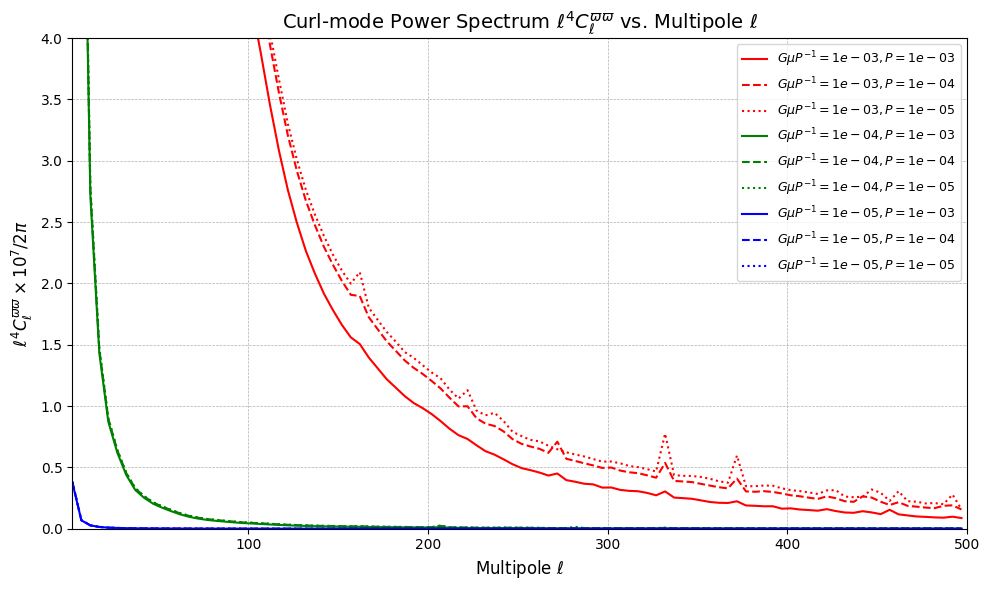

In [8]:
# ------------------------------
# Parameters for GμP⁻¹ and P
# ------------------------------
GmuP_inv_values = [1e-3, 1e-4, 1e-5]
P_values = [1e-3, 1e-4, 1e-5]
linestyles = ['-', '--', ':']
colors = ['red', 'green', 'blue']
ell_range = np.arange(2, 501, 5) 

# ------------------------------
# Plotting
# ------------------------------
plt.figure(figsize=(10, 6))

for idx, GmuP_inv in enumerate(GmuP_inv_values):
    for jdx, P in enumerate(P_values):
        G_mu = GmuP_inv * P
        label = rf"$G\mu P^{{-1}} = {GmuP_inv:.0e}, P = {P:.0e}$"
        spectrum = [compute_cl_ell(l, G_mu, P) for l in ell_range]
        plt.plot(ell_range, spectrum,
                 linestyle=linestyles[jdx],
                 color=colors[idx],
                 label=label)

plt.title(r'Curl-mode Power Spectrum $\ell^4 C_\ell^{\varpi\varpi}$ vs. Multipole $\ell$', fontsize=14)
plt.xlabel(r'Multipole $\ell$', fontsize=12)
plt.ylabel(r'$\ell^4 C_\ell^{\varpi\varpi} \times 10^7 / 2\pi$', fontsize=12)
plt.ylim(0, 4)
plt.xlim(2, 500)
plt.legend(fontsize=9, loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("curl_mode_spectrum.png", dpi=300, bbox_inches='tight')
plt.show()